In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

zip_path = "/content/drive/MyDrive/SE4050_FER_Project/archive.zip"

print("File exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"ZIP size: {size_mb:.2f} MB")

File exists: True
ZIP size: 60.32 MB


In [6]:
import zipfile

zip_path = "/content/drive/MyDrive/SE4050_FER_Project/archive.zip"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        bad_file = zip_ref.testzip()

        if bad_file is None:
            print("ZIP file is valid!")
        else:
            print("Corrupted file found:", bad_file)

except zipfile.BadZipFile:
    print("The ZIP file is corrupted.")

ZIP file is valid!


In [7]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/SE4050_FER_Project/archive.zip"
extract_path = "/content/fer2013"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("FER-2013 extracted successfully!")

FER-2013 extracted successfully!


In [8]:
print(os.listdir("/content/fer2013"))

['train', 'test']


In [9]:
train_path = "/content/fer2013/train"
test_path = "/content/fer2013/test"

print("Training classes:")
print(sorted(os.listdir(train_path)))

print("\nTest classes:")
print(sorted(os.listdir(test_path)))

Training classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [10]:
def count_images(directory):
    total = 0

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

            print(f"{class_name:<12}: {count}")
            total += count

    print("-" * 25)
    print(f"{'TOTAL':<12}: {total}")


print("TRAINING DATA")
count_images(train_path)

print("\nTEST DATA")
count_images(test_path)

TRAINING DATA
angry       : 3995
disgust     : 436
fear        : 4097
happy       : 7215
neutral     : 4965
sad         : 4830
surprise    : 3171
-------------------------
TOTAL       : 28709

TEST DATA
angry       : 958
disgust     : 111
fear        : 1024
happy       : 1774
neutral     : 1233
sad         : 1247
surprise    : 831
-------------------------
TOTAL       : 7178


In [11]:
import os

DATA_DIR = "/content/fer2013"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

print("\nTrain classes:")
print(sorted(os.listdir(TRAIN_DIR)))

print("\nTest classes:")
print(sorted(os.listdir(TEST_DIR)))

Train exists: True
Test exists: True

Train classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Test classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [12]:
import pandas as pd

def get_class_counts(directory):
    counts = {}

    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            counts[class_name] = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

    return counts


train_counts = get_class_counts(TRAIN_DIR)
test_counts = get_class_counts(TEST_DIR)

distribution_df = pd.DataFrame({
    "Train": pd.Series(train_counts),
    "Test": pd.Series(test_counts)
})

distribution_df

,Train,Test
angry,3995,958
disgust,436,111
fear,4097,1024
happy,7215,1774
neutral,4965,1233
sad,4830,1247
surprise,3171,831


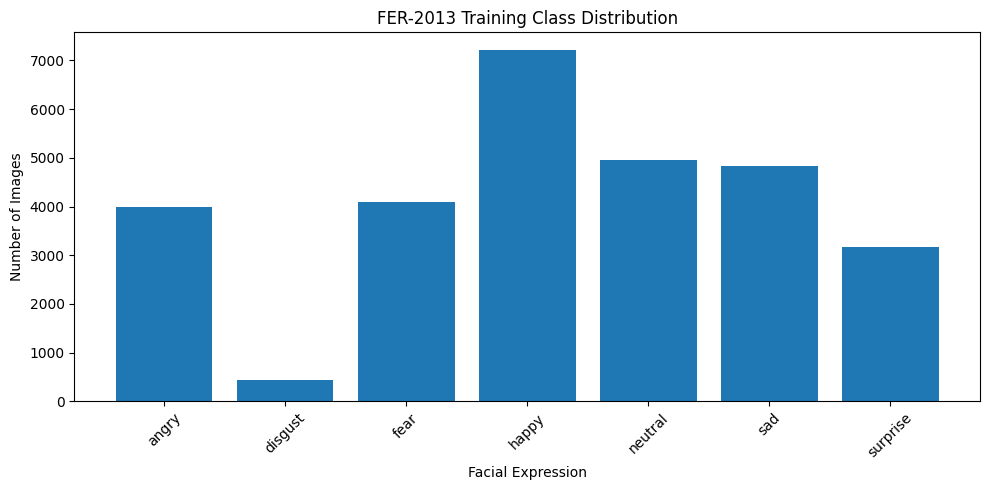

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(train_counts.keys(), train_counts.values())

plt.title("FER-2013 Training Class Distribution")
plt.xlabel("Facial Expression")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

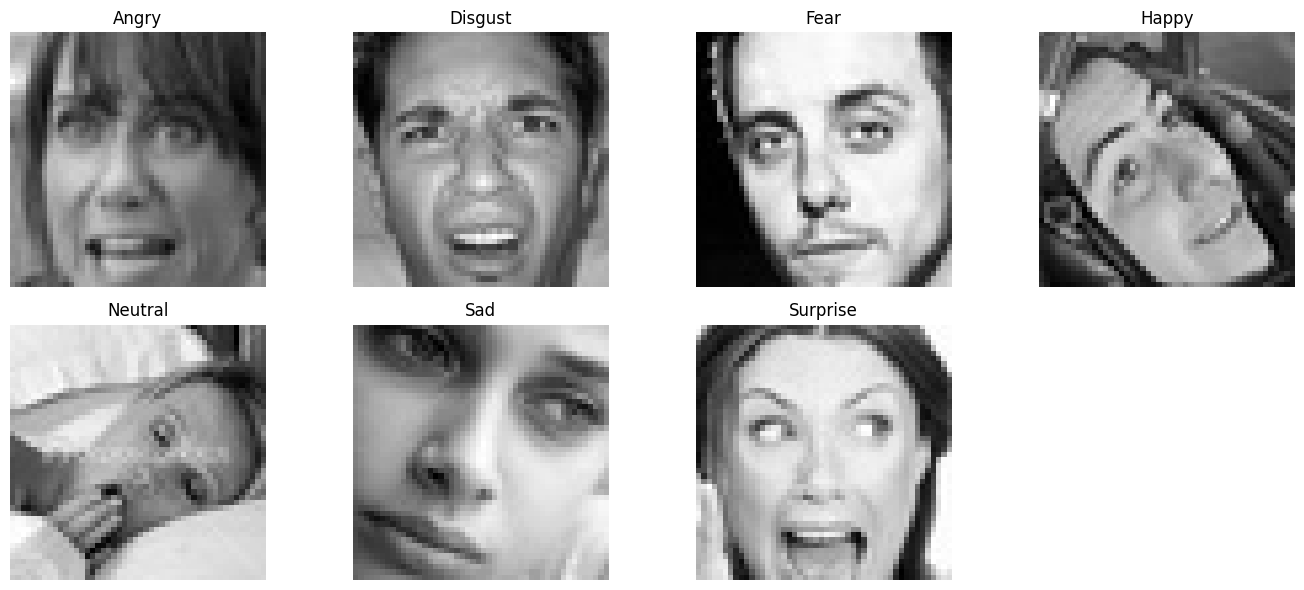

In [14]:
from PIL import Image
import random

classes = sorted(os.listdir(TRAIN_DIR))

plt.figure(figsize=(14, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)

    image_files = os.listdir(class_path)
    random_image = random.choice(image_files)

    img = Image.open(
        os.path.join(class_path, random_image)
    )

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(class_name.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
sample_class = classes[0]
sample_file = os.listdir(
    os.path.join(TRAIN_DIR, sample_class)
)[0]

sample_path = os.path.join(
    TRAIN_DIR,
    sample_class,
    sample_file
)

img = Image.open(sample_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (48, 48)
Image mode: L


In [16]:
from collections import Counter

size_counter = Counter()
mode_counter = Counter()

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    for filename in os.listdir(class_path):
        file_path = os.path.join(class_path, filename)

        try:
            with Image.open(file_path) as img:
                size_counter[img.size] += 1
                mode_counter[img.mode] += 1
        except Exception as e:
            print("Problem image:", file_path)

print("Image sizes:")
print(size_counter)

print("\nImage modes:")
print(mode_counter)

Image sizes:
Counter({(48, 48): 28709})

Image modes:
Counter({'L': 28709})


In [17]:
SEED = 42

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

VALIDATION_SPLIT = 0.20

In [18]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


## 5. Class Distribution and Imbalance Analysis

The distribution of FER-2013 training samples is analyzed to identify
class imbalance before preprocessing and model development.

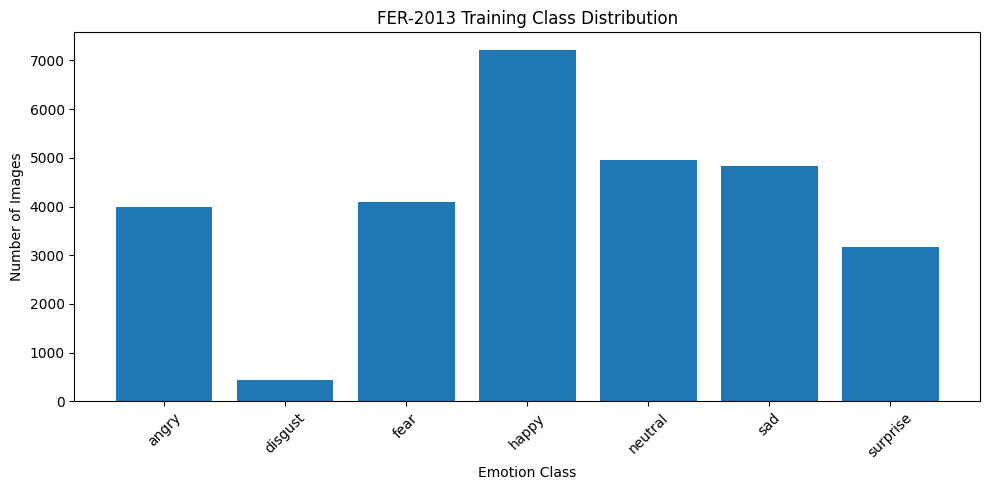

In [19]:
import matplotlib.pyplot as plt

class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

train_counts = [
    3995,
    436,
    4097,
    7215,
    4965,
    4830,
    3171
]

plt.figure(figsize=(10, 5))
plt.bar(class_names, train_counts)

plt.title("FER-2013 Training Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The FER-2013 training dataset is imbalanced across the seven emotion
classes. Happy contains the largest number of training samples (7,215),
while Disgust contains only 436 samples. This imbalance may cause the
model to learn majority classes more effectively than minority classes.

Therefore, model performance should not be evaluated using accuracy
alone. Precision, recall, F1-score, per-class performance, and the
confusion matrix will also be considered during evaluation.

In [20]:
import pandas as pd

distribution_df = pd.DataFrame({
    "Emotion": class_names,
    "Count": train_counts
})

distribution_df["Percentage"] = (
    distribution_df["Count"]
    / distribution_df["Count"].sum()
    * 100
).round(2)

distribution_df

,Emotion,Count,Percentage
0,angry,3995,13.92
1,disgust,436,1.52
2,fear,4097,14.27
3,happy,7215,25.13
4,neutral,4965,17.29
5,sad,4830,16.82
6,surprise,3171,11.05


In [21]:
from PIL import Image
import os

sample_class = "happy"

sample_folder = os.path.join(train_path, sample_class)
sample_file = os.listdir(sample_folder)[0]

sample_path = os.path.join(
    sample_folder,
    sample_file
)

sample_image = Image.open(sample_path)

print("Filename:", sample_file)
print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Filename: Training_84609076.jpg
Image size: (48, 48)
Image mode: L


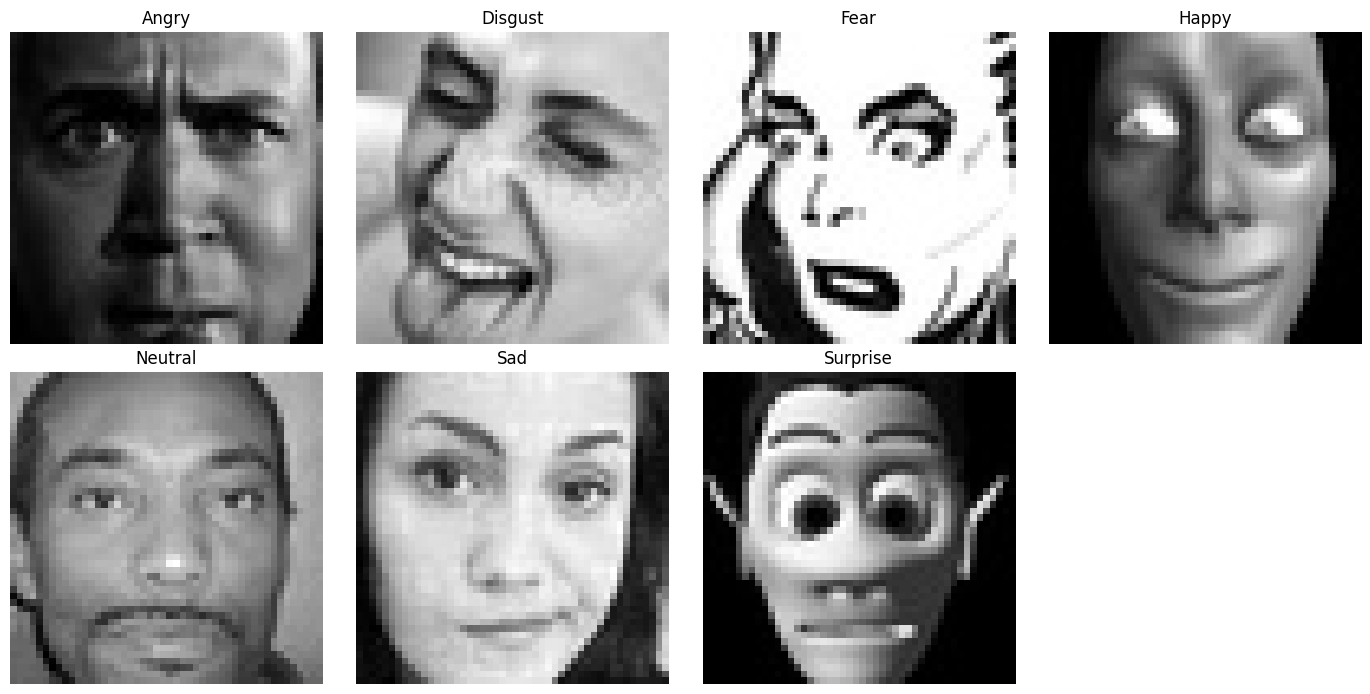

In [22]:
plt.figure(figsize=(14, 7))

for i, emotion in enumerate(class_names):

    folder = os.path.join(train_path, emotion)

    image_files = [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))
    ]

    image_path = os.path.join(
        folder,
        image_files[0]
    )

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(emotion.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

## EDA Summary

The FER-2013 dataset used in this experiment contains 28,709 training
images and 7,178 test images across seven facial-expression classes:
Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise.

The images are low-resolution grayscale facial images. Class-distribution
analysis indicates considerable imbalance, particularly for the Disgust
class, which contains substantially fewer training examples than the
other classes.

These characteristics will be considered during preprocessing, model
training, and evaluation. The original test set will remain separate
from model development and will only be used for final evaluation.

# Part 2 — EfficientNetB0 Model Development

## 6. Data Preprocessing

EfficientNetB0 will be trained using transfer learning. The original
FER-2013 images are 48 × 48 grayscale images. The input pipeline will
adapt these images to the input representation required by the selected
EfficientNetB0 configuration.

The existing FER-2013 test set is reserved for final evaluation.
Validation data is created only from the original training set.

In [23]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Validation split:", VALIDATION_SPLIT)
print("Random seed:", SEED)

Image size: (224, 224)
Batch size: 32
Validation split: 0.2
Random seed: 42


In [24]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.


In [25]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical"
)

Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [26]:
validation_split=0.20
seed=42

In [27]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [28]:
shuffle=False

In [29]:
class_names = train_ds.class_names

print("Class names:")
print(class_names)

print("\nNumber of classes:")
print(len(class_names))

Class names:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Number of classes:
7


In [30]:
assert train_ds.class_names == val_ds.class_names
assert train_ds.class_names == test_ds.class_names

print("Class mappings are consistent.")

Class mappings are consistent.


In [31]:
for images, labels in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 7)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


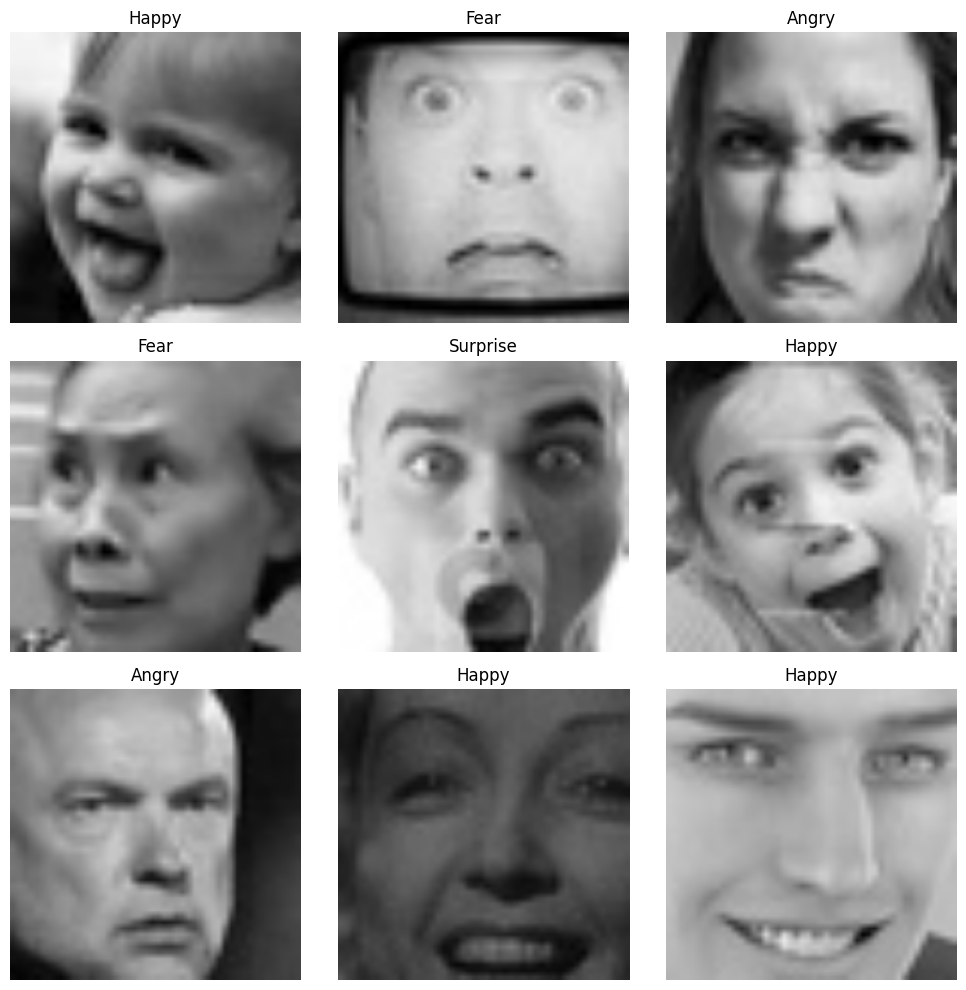

In [32]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label_index = tf.argmax(labels[i]).numpy()

        plt.title(
            class_names[label_index].capitalize()
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")

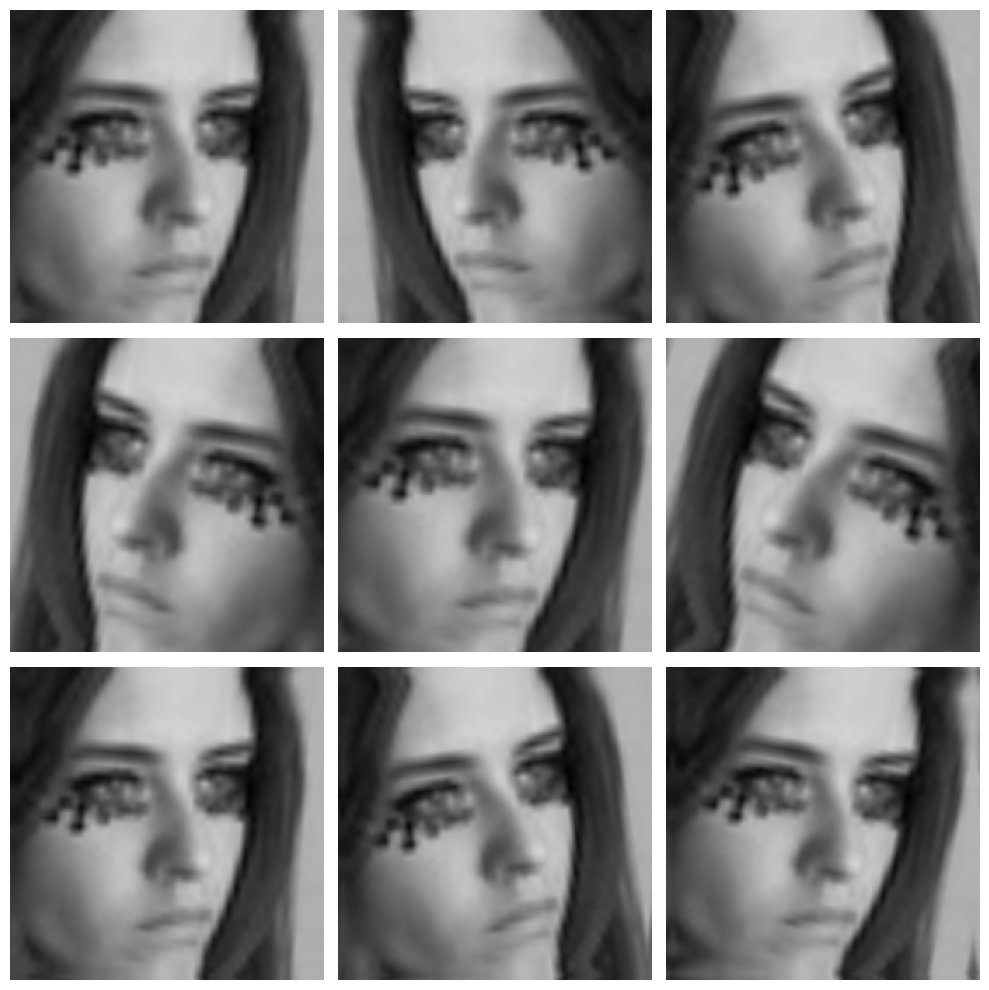

In [34]:
for images, labels in train_ds.take(1):

    plt.figure(figsize=(10, 10))

    sample_image = images[0]

    for i in range(9):

        augmented = data_augmentation(
            tf.expand_dims(sample_image, 0),
            training=True
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(
            augmented[0].numpy().astype("uint8")
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    break

In [35]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset pipelines prepared.")

Dataset pipelines prepared.


# Part 3 — EfficientNetB0 Model Development

## 7. Baseline Transfer Learning Model

EfficientNetB0 pretrained on ImageNet is used as the feature-extraction
backbone. During the initial training stage, the pretrained backbone is
frozen and only the newly added classification head is trained on the
FER-2013 dataset.

This provides a baseline before fine-tuning selected EfficientNetB0
layers.

In [36]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [37]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("EfficientNetB0 loaded successfully.")
print("Number of backbone layers:", len(base_model.layers))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 loaded successfully.
Number of backbone layers: 238


In [38]:
NUM_CLASSES = len(class_names)

inputs = layers.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.4,
    name="dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="emotion_classifier"
)(x)

model = models.Model(
    inputs,
    outputs,
    name="FER_EfficientNetB0"
)

In [39]:
model.summary()

Model: "FER_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_classifier (Dense)      │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [40]:
print("Total parameters:",
      model.count_params())

print("Trainable parameters:",
      sum(tf.keras.backend.count_params(w)
          for w in model.trainable_weights))

print("Non-trainable parameters:",
      sum(tf.keras.backend.count_params(w)
          for w in model.non_trainable_weights))

Total parameters: 4058538
Trainable parameters: 8967
Non-trainable parameters: 4049571.0


In [41]:
INITIAL_LR = 1e-3

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LR
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### Initial Training Configuration

- **Optimizer:** Adam
- **Initial learning rate:** 0.001
- **Loss function:** Categorical Cross-Entropy
- **Output activation:** Softmax
- **Batch size:** 32
- **Input resolution:** 224 × 224
- **Backbone:** EfficientNetB0 pretrained on ImageNet
- **Backbone status:** Frozen
- **Dropout:** 0.4

Categorical cross-entropy is used because FER-2013 is a seven-class
single-label classification problem represented using categorical
labels.

In [42]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [43]:
import os

MODEL_DIR = "/content/efficientnet_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

BASELINE_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "efficientnetb0_baseline_best.keras"
)

In [44]:
baseline_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        BASELINE_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [45]:
import time

INITIAL_EPOCHS = 20

start_time = time.time()

history_baseline = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=baseline_callbacks
)

baseline_training_time = (
    time.time() - start_time
)

print(
    f"\nBaseline training time: "
    f"{baseline_training_time / 60:.2f} minutes"
)

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3372 - loss: 1.6895
Epoch 1: val_loss improved from None to 1.42067, saving model to /content/efficientnet_models/efficientnetb0_baseline_best.keras

Epoch 1: finished saving model to /content/efficientnet_models/efficientnetb0_baseline_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 92s 111ms/step - accuracy: 0.3791 - loss: 1.5968 - val_accuracy: 0.4745 - val_loss: 1.4207 - learning_rate: 0.0010
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4358 - loss: 1.4846
Epoch 2: val_loss improved from 1.42067 to 1.35868, saving model to /content/efficientnet_models/efficientnetb0_baseline_best.keras

Epoch 2: finished saving model to /content/efficientnet_models/efficientnetb0_baseline_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 135s 105ms/step - accuracy: 0.4359 - loss: 1.4737 - val_accuracy: 0.5037 - val_loss: 1.3587 - learning_rate: 0.0010
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4469 - loss

In [46]:
best_epoch = (
    np.argmin(history_baseline.history["val_loss"])
    + 1
)

best_val_loss = min(
    history_baseline.history["val_loss"]
)

best_val_accuracy = max(
    history_baseline.history["val_accuracy"]
)

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Best validation accuracy:", best_val_accuracy)

Best epoch: 20
Best validation loss: 1.2842693328857422
Best validation accuracy: 0.5201184749603271


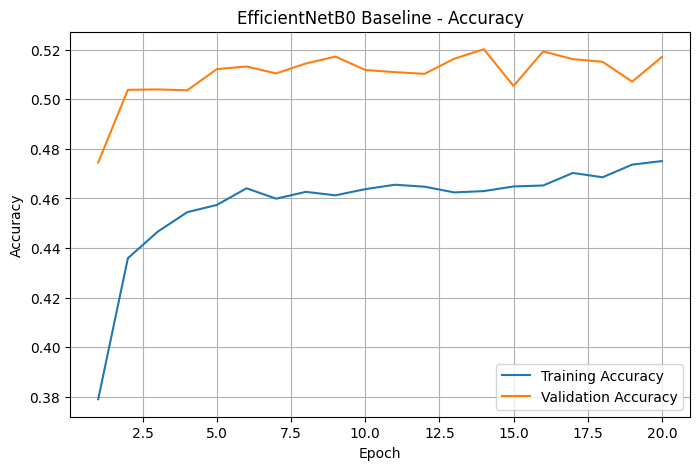

In [47]:
train_acc = history_baseline.history["accuracy"]
val_acc = history_baseline.history["val_accuracy"]

epochs_range = range(
    1,
    len(train_acc) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_acc,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_acc,
    label="Validation Accuracy"
)

plt.title(
    "EfficientNetB0 Baseline - Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

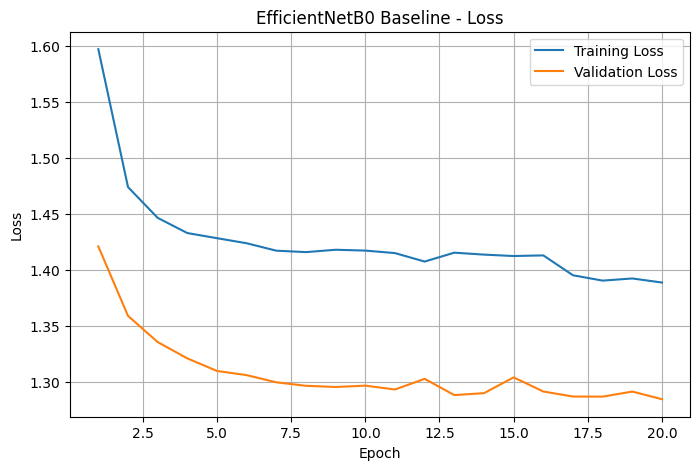

In [48]:
train_loss = history_baseline.history["loss"]
val_loss = history_baseline.history["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_loss,
    label="Validation Loss"
)

plt.title(
    "EfficientNetB0 Baseline - Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

In [49]:
val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(
    f"Validation Loss: {val_loss:.4f}"
)

print(
    f"Validation Accuracy: {val_accuracy:.4f}"
)

180/180 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.5170 - loss: 1.2843
Validation Loss: 1.2843
Validation Accuracy: 0.5170


In [50]:
from sklearn.metrics import (
    classification_report,
    f1_score
)

y_val_true = []
y_val_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_val_true.extend(
        np.argmax(
            labels.numpy(),
            axis=1
        )
    )

    y_val_pred.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

y_val_true = np.array(y_val_true)
y_val_pred = np.array(y_val_pred)

In [51]:
print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     0.4850    0.2497    0.3297       777
     disgust     1.0000    0.1096    0.1975        73
        fear     0.4100    0.2525    0.3125       812
       happy     0.5719    0.8288    0.6768      1402
     neutral     0.4513    0.5510    0.4962      1000
         sad     0.4415    0.4317    0.4365       996
    surprise     0.6898    0.6138    0.6496       681

    accuracy                         0.5170      5741
   macro avg     0.5785    0.4339    0.4427      5741
weighted avg     0.5130    0.5170    0.4958      5741



In [52]:
baseline_macro_f1 = f1_score(
    y_val_true,
    y_val_pred,
    average="macro"
)

print(
    f"Baseline Validation Macro F1: "
    f"{baseline_macro_f1:.4f}"
)

Baseline Validation Macro F1: 0.4427


## EfficientNetB0 Experiment Log

In [53]:
experiment_results = pd.DataFrame([
    {
        "Experiment": "E1 - Frozen Baseline",
        "Backbone": "EfficientNetB0",
        "Pretrained": "ImageNet",
        "Trainable Backbone Layers": 0,
        "Initial Learning Rate": INITIAL_LR,
        "Dropout": 0.4,
        "Batch Size": BATCH_SIZE,
        "Best Epoch": best_epoch,
        "Validation Accuracy": val_accuracy,
        "Validation Macro F1": baseline_macro_f1,
        "Training Time (min)": baseline_training_time / 60
    }
])

experiment_results

,Experiment,Backbone,Pretrained,Trainable Backbone Layers,Initial Learning Rate,Dropout,Batch Size,Best Epoch,Validation Accuracy,Validation Macro F1,Training Time (min)
0,E1 - Frozen Baseline,EfficientNetB0,ImageNet,0,0.001,0.4,32,20,0.516983,0.442677,26.758291


# Experiment 2 — Fine-Tuning EfficientNetB0

In Experiment 1, the ImageNet-pretrained EfficientNetB0 backbone was
frozen and used as a feature extractor.

In Experiment 2, selected later layers of the EfficientNetB0 backbone
are unfrozen and fine-tuned using a lower learning rate. This allows
higher-level pretrained features to adapt to the FER-2013 facial
expression recognition task.

The test dataset remains unused during model selection.

In [54]:
print("Baseline Validation Accuracy:",
      round(val_accuracy, 4))

print("Baseline Validation Macro F1:",
      round(baseline_macro_f1, 4))

print("Baseline Best Epoch:",
      best_epoch)

Baseline Validation Accuracy: 0.517
Baseline Validation Macro F1: 0.4427
Baseline Best Epoch: 20


In [55]:
base_model.trainable = False

In [56]:
base_model.trainable = True

print("Total EfficientNetB0 layers:",
      len(base_model.layers))

Total EfficientNetB0 layers: 238


In [57]:
FINE_TUNE_LAYERS = 30

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    layer.trainable = True

In [58]:
trainable_backbone_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Trainable EfficientNetB0 layers:",
    trainable_backbone_layers
)

Trainable EfficientNetB0 layers: 30


In [60]:
FINE_TUNE_LR = 1e-5

In [61]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled.")
print("Learning rate:", FINE_TUNE_LR)

Fine-tuning model compiled.
Learning rate: 1e-05


In [62]:
FINE_TUNE_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "efficientnetb0_finetuned_best.keras"
)

In [63]:
finetune_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        FINE_TUNE_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [64]:
FINE_TUNE_EPOCHS = 15

start_time = time.time()

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=finetune_callbacks
)

finetune_training_time = (
    time.time() - start_time
)

print(
    f"Fine-tuning time: "
    f"{finetune_training_time / 60:.2f} minutes"
)

Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3212 - loss: 1.8424
Epoch 1: val_loss improved from None to 1.40516, saving model to /content/efficientnet_models/efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to /content/efficientnet_models/efficientnetb0_finetuned_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 108s 128ms/step - accuracy: 0.3511 - loss: 1.7420 - val_accuracy: 0.4708 - val_loss: 1.4052 - learning_rate: 1.0000e-05
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4070 - loss: 1.5826
Epoch 2: val_loss improved from 1.40516 to 1.32297, saving model to /content/efficientnet_models/efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to /content/efficientnet_models/efficientnetb0_finetuned_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 138s 124ms/step - accuracy: 0.4199 - loss: 1.5505 - val_accuracy: 0.5008 - val_loss: 1.3230 - learning_rate: 1.0000e-05
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accurac

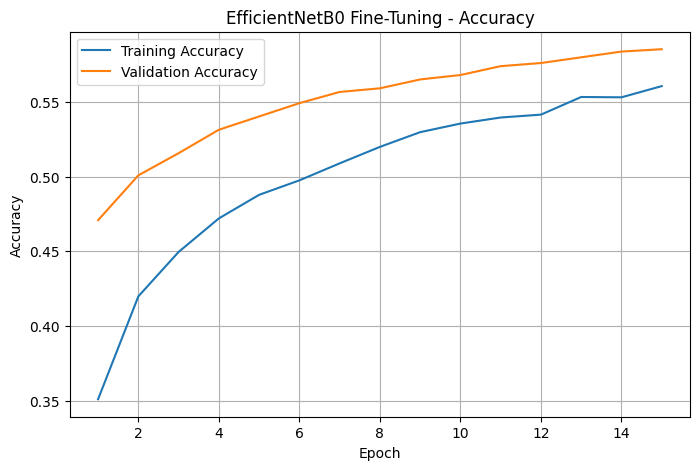

In [65]:
ft_train_acc = history_finetune.history["accuracy"]
ft_val_acc = history_finetune.history["val_accuracy"]

ft_epochs = range(
    1,
    len(ft_train_acc) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    ft_epochs,
    ft_train_acc,
    label="Training Accuracy"
)

plt.plot(
    ft_epochs,
    ft_val_acc,
    label="Validation Accuracy"
)

plt.title(
    "EfficientNetB0 Fine-Tuning - Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

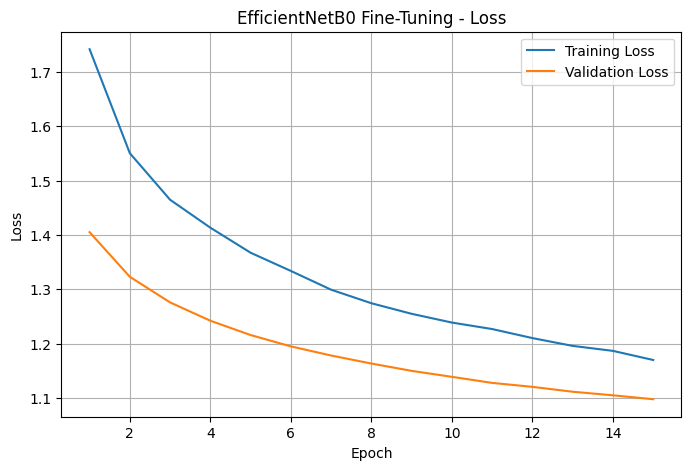

In [66]:
ft_train_loss = history_finetune.history["loss"]
ft_val_loss = history_finetune.history["val_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    ft_epochs,
    ft_train_loss,
    label="Training Loss"
)

plt.plot(
    ft_epochs,
    ft_val_loss,
    label="Validation Loss"
)

plt.title(
    "EfficientNetB0 Fine-Tuning - Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [67]:
best_ft_epoch = (
    np.argmin(
        history_finetune.history["val_loss"]
    ) + 1
)

best_ft_val_loss = min(
    history_finetune.history["val_loss"]
)

best_ft_val_accuracy = max(
    history_finetune.history["val_accuracy"]
)

print("Best fine-tuning epoch:",
      best_ft_epoch)

print("Best fine-tuning validation loss:",
      best_ft_val_loss)

print("Best fine-tuning validation accuracy:",
      best_ft_val_accuracy)

Best fine-tuning epoch: 15
Best fine-tuning validation loss: 1.0975836515426636
Best fine-tuning validation accuracy: 0.5850896835327148


In [68]:
finetuned_model = tf.keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [69]:
ft_val_loss, ft_val_accuracy = (
    finetuned_model.evaluate(
        val_ds,
        verbose=1
    )
)

print(
    f"Fine-Tuned Validation Loss: "
    f"{ft_val_loss:.4f}"
)

print(
    f"Fine-Tuned Validation Accuracy: "
    f"{ft_val_accuracy:.4f}"
)

180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.5851 - loss: 1.0976
Fine-Tuned Validation Loss: 1.0976
Fine-Tuned Validation Accuracy: 0.5851


In [70]:
y_val_true_ft = []
y_val_pred_ft = []

for images, labels in val_ds:

    predictions = finetuned_model.predict(
        images,
        verbose=0
    )

    y_val_true_ft.extend(
        np.argmax(
            labels.numpy(),
            axis=1
        )
    )

    y_val_pred_ft.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

y_val_true_ft = np.array(
    y_val_true_ft
)

y_val_pred_ft = np.array(
    y_val_pred_ft
)

In [71]:
print(
    classification_report(
        y_val_true_ft,
        y_val_pred_ft,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     0.5298    0.4582    0.4914       777
     disgust     0.6667    0.1370    0.2273        73
        fear     0.4566    0.3177    0.3747       812
       happy     0.7576    0.8359    0.7948      1402
     neutral     0.5084    0.6020    0.5513      1000
         sad     0.4479    0.4789    0.4629       996
    surprise     0.6984    0.7107    0.7045       681

    accuracy                         0.5851      5741
   macro avg     0.5808    0.5058    0.5153      5741
weighted avg     0.5789    0.5851    0.5764      5741



In [72]:
finetuned_macro_f1 = f1_score(
    y_val_true_ft,
    y_val_pred_ft,
    average="macro"
)

print(
    f"Fine-Tuned Validation Macro F1: "
    f"{finetuned_macro_f1:.4f}"
)

Fine-Tuned Validation Macro F1: 0.5153


In [73]:
new_result = pd.DataFrame([
    {
        "Experiment": "E2 - Fine-Tuned Last 30",
        "Backbone": "EfficientNetB0",
        "Pretrained": "ImageNet",
        "Trainable Backbone Layers": 30,
        "Initial Learning Rate": FINE_TUNE_LR,
        "Dropout": 0.4,
        "Batch Size": BATCH_SIZE,
        "Best Epoch": best_ft_epoch,
        "Validation Accuracy": ft_val_accuracy,
        "Validation Macro F1": finetuned_macro_f1,
        "Training Time (min)": finetune_training_time / 60
    }
])

experiment_results = pd.concat(
    [experiment_results, new_result],
    ignore_index=True
)

experiment_results

,Experiment,Backbone,Pretrained,Trainable Backbone Layers,Initial Learning Rate,Dropout,Batch Size,Best Epoch,Validation Accuracy,Validation Macro F1,Training Time (min)
0,E1 - Frozen Baseline,EfficientNetB0,ImageNet,0,0.00100,0.4,32,20,0.516983,0.442677,26.758291
1,E2 - Fine-Tuned Last 30,EfficientNetB0,ImageNet,30,0.00001,0.4,32,15,0.585090,0.515271,26.110738


In [74]:
accuracy_change = (
    ft_val_accuracy - val_accuracy
)

f1_change = (
    finetuned_macro_f1
    - baseline_macro_f1
)

print(
    f"Validation Accuracy Change: "
    f"{accuracy_change:+.4f}"
)

print(
    f"Validation Macro F1 Change: "
    f"{f1_change:+.4f}"
)

Validation Accuracy Change: +0.0681
Validation Macro F1 Change: +0.0726


## Comparison of Experiments 1 and 2

Fine-tuning the final 30 layers of EfficientNetB0 improved validation
performance compared with the frozen baseline.

- E1 Validation Accuracy: 51.70%
- E2 Validation Accuracy: 58.51%
- E1 Validation Macro F1: 44.27%
- E2 Validation Macro F1: 51.53%

Fine-tuning therefore increased validation accuracy by approximately
6.81 percentage points and Macro F1 by approximately 7.26 percentage
points.

This suggests that allowing higher-level EfficientNetB0 features to
adapt to the FER-2013 domain was beneficial. However, the dataset is
strongly imbalanced, particularly for the Disgust class. Therefore,
Experiment 3 investigates whether class weighting can improve balanced
per-class performance.

# Experiment 3 — Class-Weighted Fine-Tuning

FER-2013 contains substantial class imbalance. In particular, the
Disgust class contains considerably fewer training samples than classes
such as Happy.

This experiment applies class weights during training so that errors
on underrepresented classes receive greater importance.

The architecture and fine-tuning configuration are otherwise kept
similar to Experiment 2 to provide a controlled comparison.

In [76]:
train_counts_dict = {
    "angry": 3995,
    "disgust": 436,
    "fear": 4097,
    "happy": 7215,
    "neutral": 4965,
    "sad": 4830,
    "surprise": 3171
}

total_train = sum(train_counts_dict.values())
num_classes = len(train_counts_dict)

class_weight_dict = {}

for index, class_name in enumerate(class_names):

    count = train_counts_dict[class_name]

    weight = total_train / (
        num_classes * count
    )

    class_weight_dict[index] = weight

print("Class weights:")

for index, weight in class_weight_dict.items():

    print(
        f"{index} ({class_names[index]}): "
        f"{weight:.4f}"
    )

Class weights:
0 (angry): 1.0266
1 (disgust): 9.4066
2 (fear): 1.0010
3 (happy): 0.5684
4 (neutral): 0.8260
5 (sad): 0.8491
6 (surprise): 1.2934


In [77]:
e3_model = tf.keras.models.load_model(
    BASELINE_MODEL_PATH
)

print("Baseline checkpoint loaded for Experiment 3.")

Baseline checkpoint loaded for Experiment 3.


In [78]:
for i, layer in enumerate(e3_model.layers):
    print(i, layer.name)

0 input_image
1 data_augmentation
2 efficientnetb0
3 global_average_pooling
4 dropout
5 emotion_classifier


In [79]:
e3_base_model = e3_model.get_layer(
    "efficientnetb0"
)

In [80]:
e3_base_model.trainable = True

FINE_TUNE_LAYERS = 30

for layer in e3_base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

for layer in e3_base_model.layers[-FINE_TUNE_LAYERS:]:
    layer.trainable = True

In [81]:
print(
    "Trainable backbone layers:",
    sum(
        layer.trainable
        for layer in e3_base_model.layers
    )
)

Trainable backbone layers: 30


In [82]:
E3_LR = 1e-5

e3_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=E3_LR
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [83]:
E3_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "efficientnetb0_classweighted_best.keras"
)

e3_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        E3_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [84]:
E3_EPOCHS = 15

start_time = time.time()

history_e3 = e3_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=E3_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=e3_callbacks
)

e3_training_time = (
    time.time() - start_time
)

print(
    f"E3 Training Time: "
    f"{e3_training_time / 60:.2f} minutes"
)

Epoch 1/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3020 - loss: 1.8767
Epoch 1: val_loss improved from None to 1.53720, saving model to /content/efficientnet_models/efficientnetb0_classweighted_best.keras

Epoch 1: finished saving model to /content/efficientnet_models/efficientnetb0_classweighted_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 105s 122ms/step - accuracy: 0.3207 - loss: 1.8302 - val_accuracy: 0.4121 - val_loss: 1.5372 - learning_rate: 1.0000e-05
Epoch 2/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3528 - loss: 1.6987
Epoch 2: val_loss improved from 1.53720 to 1.46130, saving model to /content/efficientnet_models/efficientnetb0_classweighted_best.keras

Epoch 2: finished saving model to /content/efficientnet_models/efficientnetb0_classweighted_best.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 88s 123ms/step - accuracy: 0.3587 - loss: 1.6867 - val_accuracy: 0.4454 - val_loss: 1.4613 - learning_rate: 1.0000e-05
Epoch 3/15
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/

In [85]:
class_weight=class_weight_dict

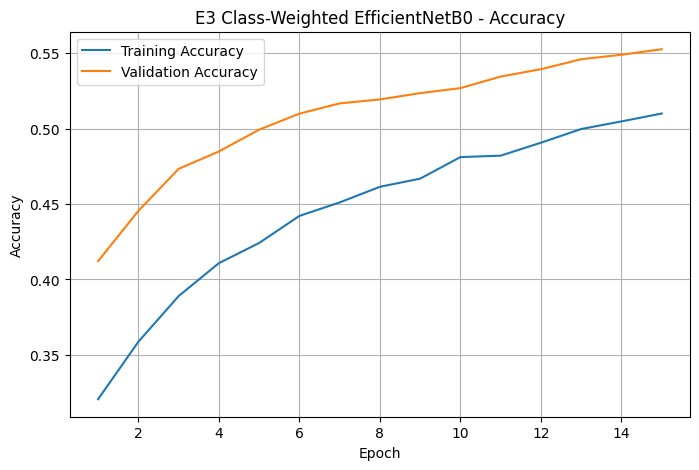

In [86]:
e3_epochs = range(
    1,
    len(history_e3.history["accuracy"]) + 1
)

plt.figure(figsize=(8,5))

plt.plot(
    e3_epochs,
    history_e3.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    e3_epochs,
    history_e3.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "E3 Class-Weighted EfficientNetB0 - Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

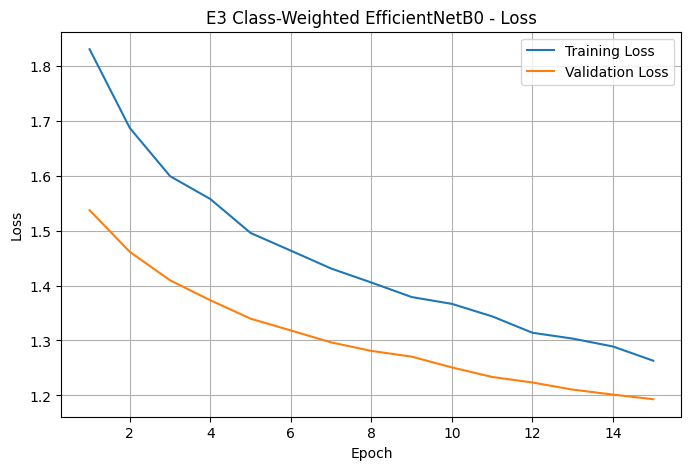

In [87]:
plt.figure(figsize=(8,5))

plt.plot(
    e3_epochs,
    history_e3.history["loss"],
    label="Training Loss"
)

plt.plot(
    e3_epochs,
    history_e3.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "E3 Class-Weighted EfficientNetB0 - Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [88]:
e3_best_model = tf.keras.models.load_model(
    E3_MODEL_PATH
)

print("Best E3 model loaded.")

Best E3 model loaded.


In [89]:
e3_val_loss, e3_val_accuracy = (
    e3_best_model.evaluate(
        val_ds,
        verbose=1
    )
)

print(
    f"E3 Validation Loss: "
    f"{e3_val_loss:.4f}"
)

print(
    f"E3 Validation Accuracy: "
    f"{e3_val_accuracy:.4f}"
)

180/180 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.5525 - loss: 1.1931
E3 Validation Loss: 1.1931
E3 Validation Accuracy: 0.5525


In [90]:
y_val_true_e3 = []
y_val_pred_e3 = []

for images, labels in val_ds:

    predictions = e3_best_model.predict(
        images,
        verbose=0
    )

    y_val_true_e3.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_val_pred_e3.extend(
        np.argmax(predictions, axis=1)
    )

y_val_true_e3 = np.array(y_val_true_e3)
y_val_pred_e3 = np.array(y_val_pred_e3)

In [91]:
print(
    classification_report(
        y_val_true_e3,
        y_val_pred_e3,
        target_names=class_names,
        digits=4
    )
)

e3_macro_f1 = f1_score(
    y_val_true_e3,
    y_val_pred_e3,
    average="macro"
)

print(
    f"E3 Validation Macro F1: "
    f"{e3_macro_f1:.4f}"
)

              precision    recall  f1-score   support

       angry     0.4896    0.4260    0.4556       777
     disgust     0.1871    0.7534    0.2997        73
        fear     0.4249    0.3030    0.3537       812
       happy     0.7939    0.7553    0.7741      1402
     neutral     0.5000    0.5740    0.5345      1000
         sad     0.4454    0.3976    0.4202       996
    surprise     0.6224    0.7504    0.6804       681

    accuracy                         0.5525      5741
   macro avg     0.4948    0.5657    0.5026      5741
weighted avg     0.5608    0.5525    0.5512      5741

E3 Validation Macro F1: 0.5026


In [92]:
best_e3_epoch = (
    np.argmin(
        history_e3.history["val_loss"]
    ) + 1
)

In [93]:
e3_result = pd.DataFrame([
    {
        "Experiment": "E3 - Class Weighted",
        "Backbone": "EfficientNetB0",
        "Pretrained": "ImageNet",
        "Trainable Backbone Layers": 30,
        "Initial Learning Rate": E3_LR,
        "Dropout": 0.4,
        "Batch Size": BATCH_SIZE,
        "Best Epoch": best_e3_epoch,
        "Validation Accuracy": e3_val_accuracy,
        "Validation Macro F1": e3_macro_f1,
        "Training Time (min)": e3_training_time / 60
    }
])

experiment_results = pd.concat(
    [experiment_results, e3_result],
    ignore_index=True
)

experiment_results

,Experiment,Backbone,Pretrained,Trainable Backbone Layers,Initial Learning Rate,Dropout,Batch Size,Best Epoch,Validation Accuracy,Validation Macro F1,Training Time (min)
0,E1 - Frozen Baseline,EfficientNetB0,ImageNet,0,0.00100,0.4,32,20,0.516983,0.442677,26.758291
1,E2 - Fine-Tuned Last 30,EfficientNetB0,ImageNet,30,0.00001,0.4,32,15,0.585090,0.515271,26.110738
2,E3 - Class Weighted,EfficientNetB0,ImageNet,30,0.00001,0.4,32,15,0.552517,0.502600,22.267481


# Final Model Selection

Three EfficientNetB0 configurations were evaluated using the validation
dataset.

- E1 – Frozen Baseline:
  Validation Accuracy = 51.70%
  Macro F1 = 44.27%

- E2 – Fine-Tuned Last 30 Layers:
  Validation Accuracy = 58.51%
  Macro F1 = 51.53%

- E3 – Class-Weighted Fine-Tuning:
  Validation Accuracy = 55.25%
  Macro F1 = 50.26%

E2 achieved the highest validation accuracy and Macro F1 among the
three experiments. Therefore, E2 was selected as the final
EfficientNetB0 configuration.

Although class weighting in E3 was introduced to address the class
imbalance identified during EDA, it did not improve overall validation
accuracy or Macro F1 compared with E2.

The selected E2 model is now evaluated on the previously unseen test
dataset.

In [94]:
FINE_TUNE_MODEL_PATH

'/content/efficientnet_models/efficientnetb0_finetuned_best.keras'

In [95]:
final_model = tf.keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print("Selected E2 model loaded successfully.")

Selected E2 model loaded successfully.


In [96]:
final_model.summary()

Model: "FER_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_classifier (Dense)      │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,068,794 (26.97 MB)

 Trainable params: 1,505,127 (5.74 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

 Optimizer params: 3,010,256 (11.48 MB)

In [97]:
final_model = tf.keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print("Selected E2 model loaded successfully.")

Selected E2 model loaded successfully.


In [98]:
final_model.summary()

Model: "FER_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion_classifier (Dense)      │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,068,794 (26.97 MB)

 Trainable params: 1,505,127 (5.74 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

 Optimizer params: 3,010,256 (11.48 MB)

In [99]:
test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7), dtype=tf.float32, name=None))>

In [100]:
test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Accuracy (%): {test_accuracy * 100:.2f}%")

225/225 ━━━━━━━━━━━━━━━━━━━━ 23s 77ms/step - accuracy: 0.5815 - loss: 1.1012
Final Test Loss: 1.1012
Final Test Accuracy: 0.5815
Final Test Accuracy (%): 58.15%


In [101]:
y_test_true = []
y_test_pred = []
y_test_prob = []

for images, labels in test_ds:

    probabilities = final_model.predict(
        images,
        verbose=0
    )

    y_test_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_test_pred.extend(
        np.argmax(probabilities, axis=1)
    )

    y_test_prob.extend(probabilities)

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)
y_test_prob = np.array(y_test_prob)

print("True labels:", y_test_true.shape)
print("Predicted labels:", y_test_pred.shape)
print("Prediction probabilities:", y_test_prob.shape)

True labels: (7178,)
Predicted labels: (7178,)
Prediction probabilities: (7178, 7)


In [102]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     0.4983    0.4468    0.4711       958
     disgust     0.6296    0.1532    0.2464       111
        fear     0.4292    0.2754    0.3355      1024
       happy     0.7686    0.8540    0.8091      1774
     neutral     0.4961    0.6188    0.5507      1233
         sad     0.4525    0.4579    0.4552      1247
    surprise     0.6921    0.7196    0.7056       831

    accuracy                         0.5815      7178
   macro avg     0.5666    0.5037    0.5105      7178
weighted avg     0.5714    0.5815    0.5699      7178



In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_accuracy = accuracy_score(
    y_test_true,
    y_test_pred
)

final_precision = precision_score(
    y_test_true,
    y_test_pred,
    average="macro"
)

final_recall = recall_score(
    y_test_true,
    y_test_pred,
    average="macro"
)

final_macro_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="macro"
)

final_weighted_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="weighted"
)

print(f"Test Accuracy:        {final_accuracy:.4f}")
print(f"Macro Precision:      {final_precision:.4f}")
print(f"Macro Recall:         {final_recall:.4f}")
print(f"Macro F1:             {final_macro_f1:.4f}")
print(f"Weighted F1:          {final_weighted_f1:.4f}")

Test Accuracy:        0.5815
Macro Precision:      0.5666
Macro Recall:         0.5037
Macro F1:             0.5105
Weighted F1:          0.5699


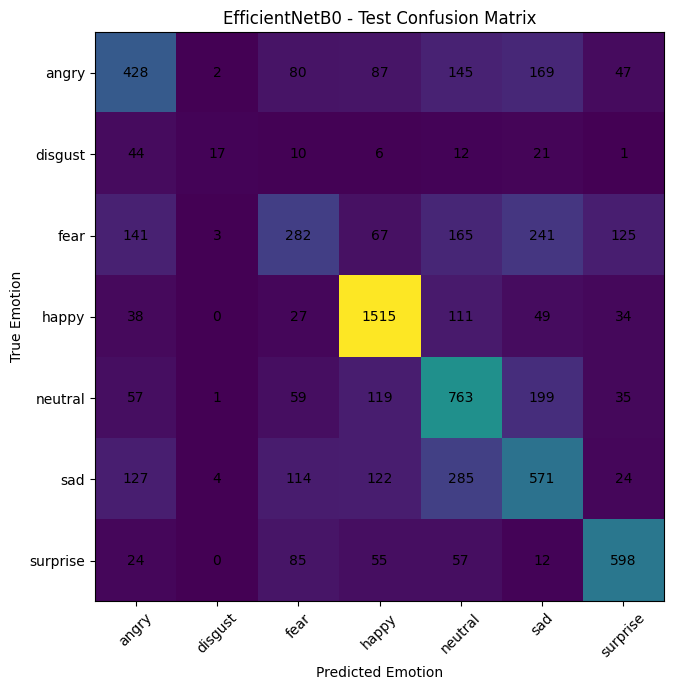

In [104]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_true,
    y_test_pred
)

plt.figure(figsize=(9, 7))
plt.imshow(cm)

plt.title(
    "EfficientNetB0 - Test Confusion Matrix"
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [105]:
report_dict = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    output_dict=True
)

per_class_results = pd.DataFrame(
    report_dict
).transpose()

per_class_results

,precision,recall,f1-score,support
angry,0.498254,0.446764,0.471106,958.000000
disgust,0.629630,0.153153,0.246377,111.000000
fear,0.429224,0.275391,0.335515,1024.000000
happy,0.768645,0.854002,0.809079,1774.000000
neutral,0.496099,0.618816,0.550704,1233.000000
sad,0.452456,0.457899,0.455161,1247.000000
surprise,0.692130,0.719615,0.705605,831.000000
accuracy,0.581499,0.581499,0.581499,0.581499
macro avg,0.566634,0.503663,0.510507,7178.000000
weighted avg,0.571382,0.581499,0.569867,7178.000000


In [106]:
from sklearn.metrics import roc_auc_score

y_test_onehot = tf.keras.utils.to_categorical(
    y_test_true,
    num_classes=len(class_names)
)

macro_roc_auc = roc_auc_score(
    y_test_onehot,
    y_test_prob,
    multi_class="ovr",
    average="macro"
)

weighted_roc_auc = roc_auc_score(
    y_test_onehot,
    y_test_prob,
    multi_class="ovr",
    average="weighted"
)

print(
    f"Macro ROC-AUC: {macro_roc_auc:.4f}"
)

print(
    f"Weighted ROC-AUC: {weighted_roc_auc:.4f}"
)

Macro ROC-AUC: 0.8777
Weighted ROC-AUC: 0.8736


In [107]:
final_results = pd.DataFrame([{
    "Model": "EfficientNetB0",
    "Configuration": "Fine-Tuned Last 30 Layers",
    "Test Accuracy": final_accuracy,
    "Macro Precision": final_precision,
    "Macro Recall": final_recall,
    "Macro F1": final_macro_f1,
    "Weighted F1": final_weighted_f1,
    "Macro ROC-AUC": macro_roc_auc
}])

final_results

,Model,Configuration,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro ROC-AUC
0,EfficientNetB0,Fine-Tuned Last 30 Layers,0.581499,0.566634,0.503663,0.510507,0.569867,0.877702


In [108]:
final_results.to_csv(
    "EfficientNetB0_Final_Test_Results.csv",
    index=False
)

In [109]:
per_class_results.to_csv(
    "EfficientNetB0_Per_Class_Results.csv"
)

print("Per-class results saved.")

Per-class results saved.


In [110]:
emotion_results = per_class_results.loc[class_names]

best_class = emotion_results["f1-score"].idxmax()
best_f1 = emotion_results.loc[best_class, "f1-score"]

weakest_class = emotion_results["f1-score"].idxmin()
weakest_f1 = emotion_results.loc[weakest_class, "f1-score"]

print(f"Best performing emotion: {best_class}")
print(f"Best F1-score: {best_f1:.4f}")

print(f"Weakest performing emotion: {weakest_class}")
print(f"Weakest F1-score: {weakest_f1:.4f}")

Best performing emotion: happy
Best F1-score: 0.8091
Weakest performing emotion: disgust
Weakest F1-score: 0.2464


In [111]:
emotion_results[
    ["precision", "recall", "f1-score", "support"]
].sort_values(
    "f1-score",
    ascending=False
)

,precision,recall,f1-score,support
happy,0.768645,0.854002,0.809079,1774.0
surprise,0.692130,0.719615,0.705605,831.0
neutral,0.496099,0.618816,0.550704,1233.0
angry,0.498254,0.446764,0.471106,958.0
sad,0.452456,0.457899,0.455161,1247.0
fear,0.429224,0.275391,0.335515,1024.0
disgust,0.629630,0.153153,0.246377,111.0


In [112]:
cm_errors = cm.copy()

# Remove correct predictions from diagonal
np.fill_diagonal(cm_errors, 0)

errors = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):

        if true_idx != pred_idx:

            errors.append({
                "True Emotion": class_names[true_idx],
                "Predicted Emotion": class_names[pred_idx],
                "Count": cm_errors[true_idx, pred_idx]
            })

error_df = pd.DataFrame(errors)

error_df = error_df.sort_values(
    "Count",
    ascending=False
)

error_df.head(10)

,True Emotion,Predicted Emotion,Count
34,sad,neutral,285
16,fear,sad,241
28,neutral,sad,199
4,angry,sad,169
15,fear,neutral,165
3,angry,neutral,145
12,fear,angry,141
30,sad,angry,127
17,fear,surprise,125
33,sad,happy,122


In [113]:
misclassified_images = []
true_labels = []
pred_labels = []

for images, labels in test_ds:

    probabilities = final_model.predict(
        images,
        verbose=0
    )

    true_batch = np.argmax(
        labels.numpy(),
        axis=1
    )

    pred_batch = np.argmax(
        probabilities,
        axis=1
    )

    for i in range(len(images)):

        if true_batch[i] != pred_batch[i]:

            misclassified_images.append(
                images[i].numpy().astype("uint8")
            )

            true_labels.append(
                class_names[true_batch[i]]
            )

            pred_labels.append(
                class_names[pred_batch[i]]
            )

        if len(misclassified_images) >= 12:
            break

    if len(misclassified_images) >= 12:
        break

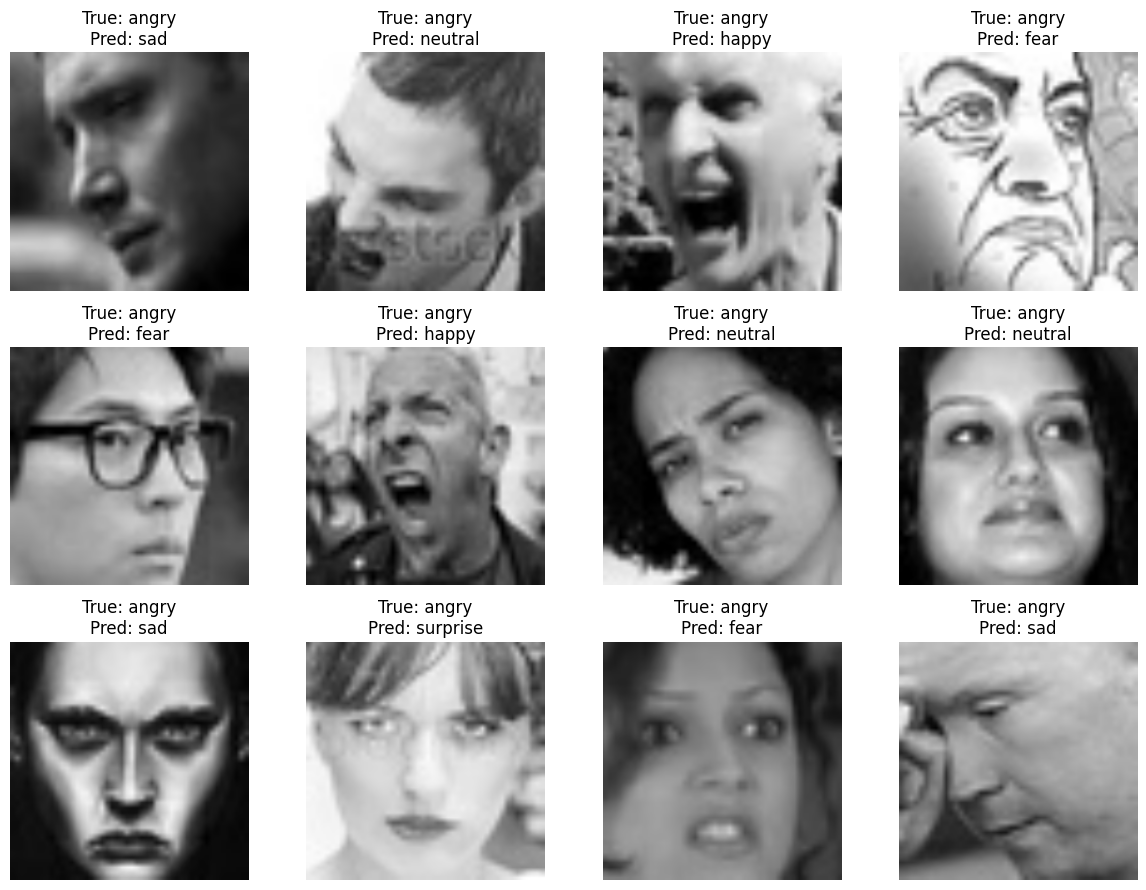

In [114]:
plt.figure(figsize=(12, 9))

for i in range(len(misclassified_images)):

    plt.subplot(3, 4, i + 1)

    plt.imshow(misclassified_images[i])

    plt.title(
        f"True: {true_labels[i]}\n"
        f"Pred: {pred_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [115]:
total_params = final_model.count_params()

trainable_params = np.sum([
    np.prod(v.shape)
    for v in final_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in final_model.non_trainable_weights
])

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-Trainable Parameters: {non_trainable_params:,}")

Total Parameters: 4,058,538
Trainable Parameters: 1,505,127
Non-Trainable Parameters: 2,553,411.0


In [116]:
for images, _ in test_ds.take(1):
    _ = final_model.predict(
        images,
        verbose=0
    )

In [117]:
start_time = time.time()

total_images = 0

for images, _ in test_ds:

    _ = final_model.predict(
        images,
        verbose=0
    )

    total_images += images.shape[0]

total_inference_time = time.time() - start_time

avg_inference_time = (
    total_inference_time / total_images
)

print(
    f"Total Images: {total_images}"
)

print(
    f"Total Inference Time: "
    f"{total_inference_time:.2f} seconds"
)

print(
    f"Average Inference Time/Image: "
    f"{avg_inference_time:.6f} seconds"
)

print(
    f"Approx. Images/Second: "
    f"{1 / avg_inference_time:.2f}"
)

Total Images: 7178
Total Inference Time: 41.01 seconds
Average Inference Time/Image: 0.005713 seconds
Approx. Images/Second: 175.05


In [118]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [119]:
efficientnet_summary = pd.DataFrame([{
    "Model": "EfficientNetB0",
    "Configuration": "Fine-Tuned Last 30 Layers",
    "Test Accuracy": final_accuracy,
    "Macro Precision": final_precision,
    "Macro Recall": final_recall,
    "Macro F1": final_macro_f1,
    "Weighted F1": final_weighted_f1,
    "Macro ROC-AUC": macro_roc_auc,
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,
    "Training Time (min)": 26.110738,
    "Inference Time/Image (s)": avg_inference_time
}])

efficientnet_summary

,Model,Configuration,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro ROC-AUC,Total Parameters,Trainable Parameters,Training Time (min),Inference Time/Image (s)
0,EfficientNetB0,Fine-Tuned Last 30 Layers,0.581499,0.566634,0.503663,0.510507,0.569867,0.877702,4058538,1505127,26.110738,0.005713


In [120]:
efficientnet_summary.to_csv(
    "EfficientNetB0_Complete_Results.csv",
    index=False
)

In [121]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [122]:
FINAL_MODEL_DIR = (
    "/content/drive/MyDrive/"
    "FER2013_Final_Models"
)

os.makedirs(
    FINAL_MODEL_DIR,
    exist_ok=True
)

In [123]:
FINAL_MODEL_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "IT23193772_EfficientNetB0_FER2013.keras"
)

final_model.save(
    FINAL_MODEL_PATH
)

print("Final model saved to:")
print(FINAL_MODEL_PATH)

Final model saved to:
/content/drive/MyDrive/FER2013_Final_Models/IT23193772_EfficientNetB0_FER2013.keras


In [124]:
verification_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

verify_loss, verify_accuracy = (
    verification_model.evaluate(
        test_ds,
        verbose=0
    )
)

print(
    f"Reloaded Model Accuracy: "
    f"{verify_accuracy:.4f}"
)

print(
    f"Original Accuracy: "
    f"{final_accuracy:.4f}"
)

Reloaded Model Accuracy: 0.5815
Original Accuracy: 0.5815


# EfficientNetB0 Final Conclusion

Three EfficientNetB0 configurations were investigated for facial
emotion recognition using the FER-2013 dataset.

### Experiment 1 — Frozen Baseline
The pretrained EfficientNetB0 backbone was initially frozen and used
as a feature extractor. This configuration achieved:

- Validation Accuracy: 51.70%
- Validation Macro F1: 44.27%

### Experiment 2 — Fine-Tuning
The final 30 layers of EfficientNetB0 were fine-tuned using a lower
learning rate. This improved performance to:

- Validation Accuracy: 58.51%
- Validation Macro F1: 51.53%

The improvement indicates that adapting the higher-level pretrained
features to facial emotion recognition was beneficial.

### Experiment 3 — Class-Weighted Fine-Tuning
Class weighting was introduced to reduce the effect of the class
imbalance identified during exploratory data analysis.

This configuration achieved:

- Validation Accuracy: 55.25%
- Validation Macro F1: 50.26%

Although class weighting was intended to improve balanced class
performance, it did not outperform Experiment 2 in validation
accuracy or Macro F1.

### Final Model Selection

Experiment 2 was selected as the final EfficientNetB0 configuration
because it achieved the highest validation accuracy and Macro F1 among
the tested configurations.

The selected model was then evaluated on the previously unseen test
set and achieved:

- Test Accuracy: 58.15%

The test accuracy was close to the validation accuracy of 58.51%,
showing similar performance between the validation and unseen test
data.

Additional per-class metrics, confusion-matrix analysis and error
analysis were used to investigate the strengths and limitations of
the final model.